# Time Series Forecasting for Personal Expenses
This notebook develops a time series forecasting model using personal transaction data. The goal is to predict future daily expenses based on historical patterns.

### Contents:
1. **Data Ingestion & Cleaning**: Preprocessing raw transaction amounts and datetimes.
2. **Data Aggregation & EDA**: Transforming transaction records into a continuous daily time series, analyzing weekly and monthly spending patterns, and performing stationarity tests.
3. **Train-Test Split**: Partitioning data for model validation.
4. **Model Training**: Fitting baseline, traditional statistical (SARIMA), and Machine Learning (Random Forest, Gradient Boosting) models.
5. **Evaluation**: Comparing models on MAE and RMSE.
6. **Future Forecasting**: Retraining the best model on all data and predicting the next 30 days.
7. **Model Export**: Saving the trained model for web application deployment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Ingestion & Cleaning
First, we load the raw CSV data, parse the date/time (handling mixed string formats), clean the transaction amounts (remove currency symbols like `Rp`, periods, and signs), and transform all values to positive expenses.

In [2]:
# Load raw transaction dataset
file_path = "Data - Excel.xlsx - Sheet1.csv"
df = pd.read_csv(file_path)

# Parse dates - handle datetime strings containing hours/minutes and raw dates
dates = pd.to_datetime(df['Tanggal Transaksi'], format='%d/%m/%Y %H:%M', errors='coerce')
dates = dates.fillna(pd.to_datetime(df['Tanggal Transaksi'], format='%d/%m/%Y', errors='coerce'))
df['Tanggal'] = dates

# Clean amount values (convert e.g., -Rp10.400 to float 10400.0)
def clean_jumlah(val):
    if pd.isna(val):
        return 0.0
    val_str = str(val).strip()
    sign = 1
    if '-' in val_str:
        sign = -1
    val_cleaned = val_str.replace('Rp', '').replace('.', '').replace('-', '').replace('+', '').strip()
    try:
        return float(val_cleaned) * sign
    except:
        return 0.0

df['Jumlah_Cleaned'] = df['Jumlah'].apply(clean_jumlah)

# Convert to absolute expense value (all raw values are negative representing spending)
df['Expense'] = df['Jumlah_Cleaned'].abs()

print(f"Data parsed successfully. Records: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Data parsed successfully. Records: 1082, Columns: 8


,Tanggal Transaksi,Transaksi,ID Transaksi,Metode Pembayaran,Jumlah,Tanggal,Jumlah_Cleaned,Expense
0,01/06/2025 17:28,GRAB TRANSPORT,0520250601102805hCvKTyW55kID,Tabungan by Jago,-Rp6.500,2025-06-01 17:28:00,-6500.0,6500.0
1,01/06/2025 18:19,GRJKTLIKSTMARINUSYHNS-H,0520250601111854vXIYQBtnk1ID,Tabungan by Jago,-Rp5.000,2025-06-01 18:19:00,-5000.0,5000.0
2,01/06/2025 19:17,GRAB TRANSPORT,0320250601121711g3KoAKvuV8ID,Tabungan by Jago,-Rp6.500,2025-06-01 19:17:00,-6500.0,6500.0
3,01/06/2025 19:22,Alfamart,0220250601122238yYs9WUkugYID,Tabungan by Jago,-Rp10.400,2025-06-01 19:22:00,-10400.0,10400.0
4,02/06/2025 09:45,GRAB TRANSPORT,0420250602024539axdcUgaAt1ID,Tabungan by Jago,-Rp6.500,2025-06-02 09:45:00,-6500.0,6500.0


## 2. Data Aggregation & EDA
Because transactions occur at irregular intervals (sometimes multiple times a day, sometimes not at all), we must aggregate the data daily. We also reindex the time series to include every single calendar day, filling missing days with `0` (indicating no money was spent).

In [3]:
# Aggregate to Daily Expense totals
daily_df = df.groupby(df['Tanggal'].dt.date)['Expense'].sum().reset_index()
daily_df.columns = ['Date', 'Expense']
daily_df['Date'] = pd.to_datetime(daily_df['Date'])
daily_df = daily_df.set_index('Date').sort_index()

# Reindex to fill any gaps in calendar dates (from min to max date) with 0
all_days = pd.date_range(start=daily_df.index.min(), end=daily_df.index.max(), freq='D')
daily_df = daily_df.reindex(all_days, fill_value=0.0)

print(f"Aggregated series details:")
print(f"- Start Date: {daily_df.index.min().strftime('%Y-%m-%d')}")
print(f"- End Date: {daily_df.index.max().strftime('%Y-%m-%d')}")
print(f"- Total Days: {len(daily_df)}")
print(f"\nSummary statistics of Daily Spending:")
print(daily_df.describe())

Aggregated series details:
- Start Date: 2025-06-01
- End Date: 2026-05-31
- Total Days: 365

Summary statistics of Daily Spending:
            Expense
count  3.650000e+02
mean   1.261798e+05
std    7.565653e+05
min    0.000000e+00
25%    5.035000e+03
50%    3.250000e+04
75%    7.200000e+04
max    1.315450e+07


### Visualizing Expense Distribution and Trends
Let's plot the daily expenses and a 7-day rolling average to smooth out noise.

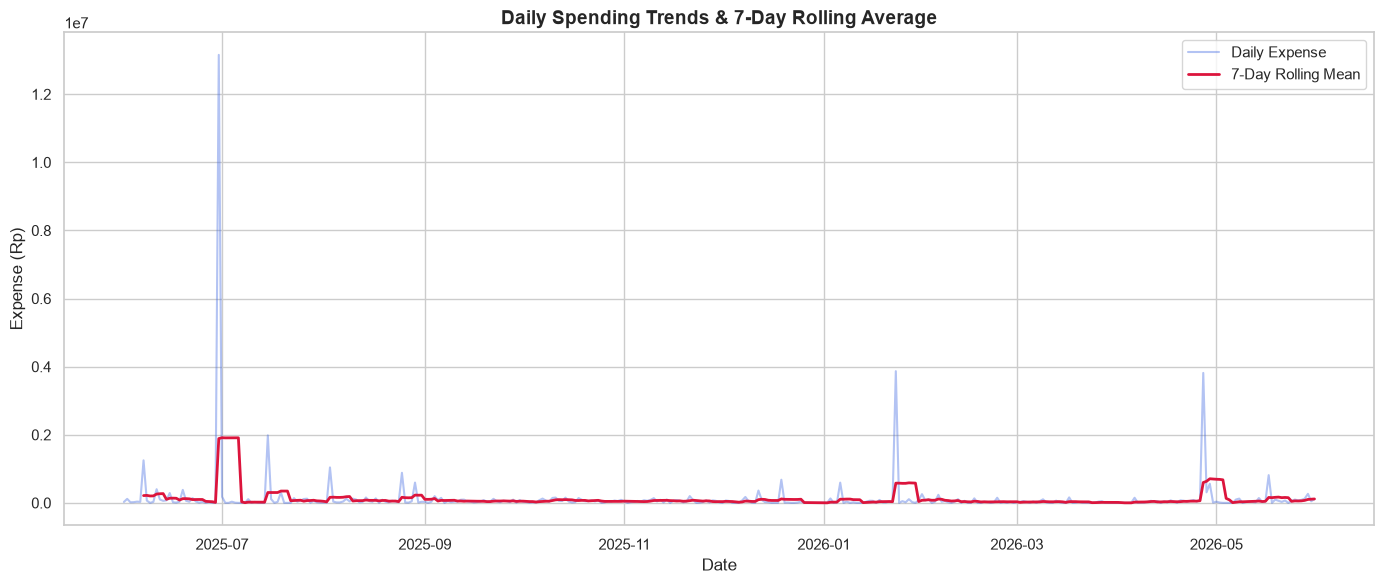

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(daily_df.index, daily_df['Expense'], label='Daily Expense', alpha=0.4, color='royalblue')
plt.plot(daily_df.index, daily_df['Expense'].rolling(7).mean(), label='7-Day Rolling Mean', color='crimson', linewidth=2)
plt.title('Daily Spending Trends & 7-Day Rolling Average', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Expense (Rp)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### Checking Weekly and Monthly Spending Patterns
Do expenses spike on specific days of the week or specific months?

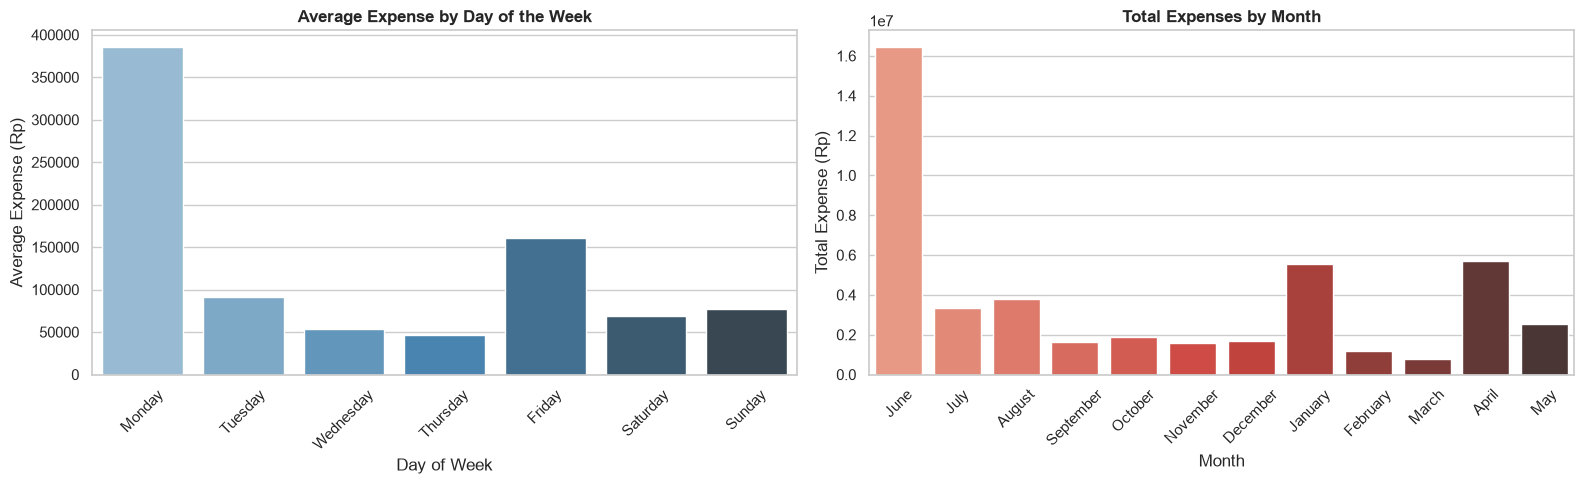

In [5]:
temp_df = daily_df.copy()
temp_df['DayOfWeek'] = temp_df.index.day_name()
temp_df['Month'] = temp_df.index.strftime('%B')

order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
order_months = ['June', 'July', 'August', 'September', 'October', 'November', 'December', 
                'January', 'February', 'March', 'April', 'May']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average Daily Expense by Day of the Week
sns.barplot(ax=axes[0], data=temp_df, x='DayOfWeek', y='Expense', order=order_days, estimator=np.mean, errorbar=None, palette='Blues_d')
axes[0].set_title('Average Expense by Day of the Week', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Expense (Rp)')
axes[0].tick_params(axis='x', rotation=45)

# Total Expense by Month
sns.barplot(ax=axes[1], data=temp_df, x='Month', y='Expense', order=order_months, estimator=np.sum, errorbar=None, palette='Reds_d')
axes[1].set_title('Total Expenses by Month', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Expense (Rp)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Testing Stationarity (ADF Test) and Seasonal Decomposition
A stationary time series is essential for statistical models like ARIMA. We perform the Augmented Dickey-Fuller (ADF) test.

Augmented Dickey-Fuller (ADF) Test:
- ADF Statistic: -19.0478
- p-value: 0.0000
- Critical Values:
   1%: -3.4484
   5%: -2.8695
   10%: -2.5710

Result: The series is STATIONARY (p-value <= 0.05). Differencing may not be strictly required.


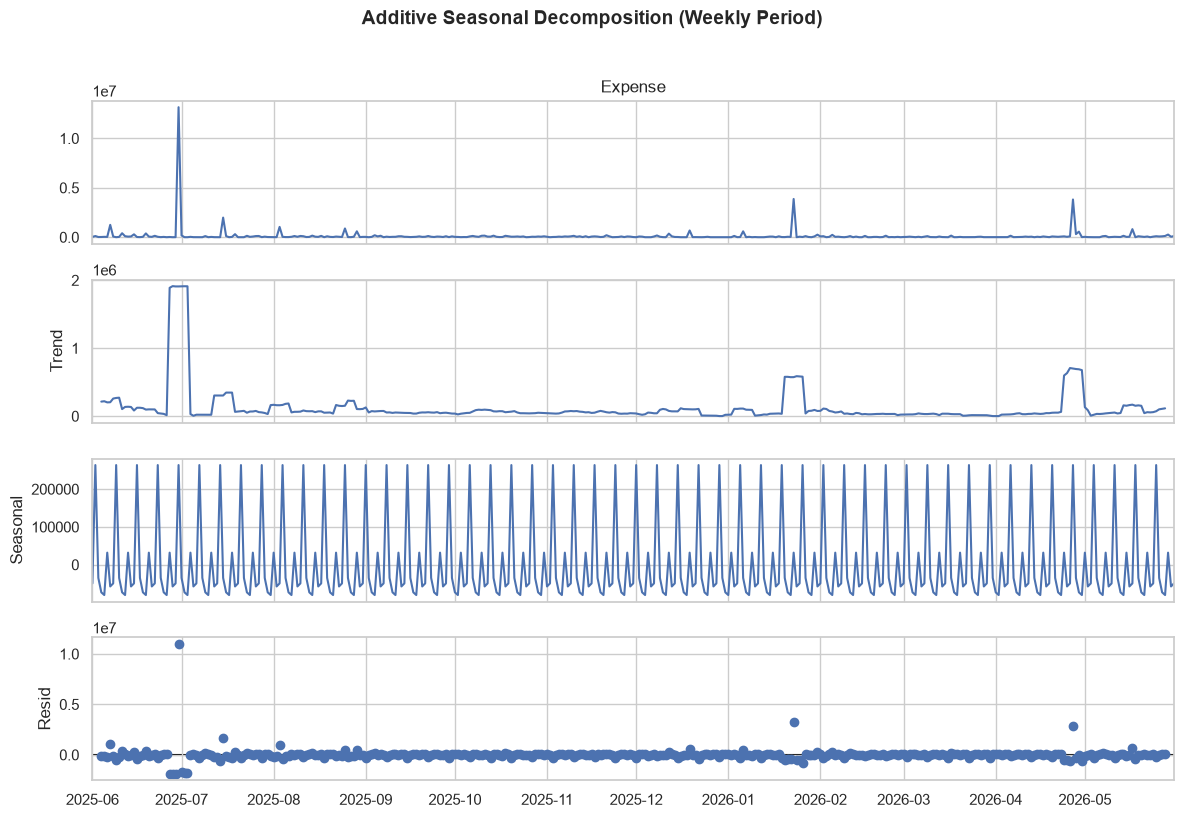

In [6]:
print("Augmented Dickey-Fuller (ADF) Test:")
adf_result = adfuller(daily_df['Expense'])
print(f'- ADF Statistic: {adf_result[0]:.4f}')
print(f'- p-value: {adf_result[1]:.4f}')
print('- Critical Values:')
for key, val in adf_result[4].items():
    print(f'   {key}: {val:.4f}')

if adf_result[1] <= 0.05:
    print("\nResult: The series is STATIONARY (p-value <= 0.05). Differencing may not be strictly required.")
else:
    print("\nResult: The series is NON-STATIONARY. We will need to difference it for ARIMA.")

# Plot seasonal decomposition
decomp = seasonal_decompose(daily_df['Expense'], model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Additive Seasonal Decomposition (Weekly Period)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Train-Test Split
We split our data sequentially. The last 30 days are held out for model evaluation, while the remaining history is used for training.

In [7]:
test_days = 30
train_size = len(daily_df) - test_days
train = daily_df.iloc[:train_size]
test = daily_df.iloc[train_size:]

print(f"Train dates: {train.index.min().strftime('%Y-%m-%d')} to {train.index.max().strftime('%Y-%m-%d')} ({len(train)} days)")
print(f"Test dates: {test.index.min().strftime('%Y-%m-%d')} to {test.index.max().strftime('%Y-%m-%d')} ({len(test)} days)")

Train dates: 2025-06-01 to 2026-05-01 (335 days)
Test dates: 2026-05-02 to 2026-05-31 (30 days)


## 4. Model Training & Evaluation

We evaluate five forecasting methods:
1. **Naive Baseline**: Historical mean daily expenditure.
2. **Holt-Winters Exponential Smoothing**: A classic statistical technique modeling trend and weekly seasonality.
3. **SARIMA (Seasonal ARIMA)**: An autoregressive model that captures trends and seasonal cycles.
4. **Random Forest Regressor**: A supervised machine learning model mapping lags and rolling statistics to target values.
5. **Gradient Boosting Regressor**: Another machine learning tree ensemble optimized sequentially.

In [8]:
# 1. Baseline Model
baseline_pred = np.full(len(test), train['Expense'].mean())

# 2. Holt-Winters ES Model
try:
    hw_model = ExponentialSmoothing(train['Expense'], trend='add', seasonal='add', seasonal_periods=7)
    hw_fit = hw_model.fit()
    hw_pred = np.clip(hw_fit.forecast(steps=len(test)), 0, None)
except Exception as e:
    print(f"Holt-Winters failed: {e}")
    hw_pred = baseline_pred

# 3. SARIMA Model
try:
    sarima_model = SARIMAX(train['Expense'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), 
                           enforce_stationarity=False, enforce_invertibility=False)
    sarima_fit = sarima_model.fit(disp=False)
    sarima_pred = np.clip(sarima_fit.forecast(steps=len(test)), 0, None)
except Exception as e:
    print(f"SARIMA failed: {e}")
    sarima_pred = baseline_pred

print("Statistical forecasting models completed.")

Statistical forecasting models completed.


### Feature Engineering for Supervised Machine Learning
To frame this as a machine learning task, we generate lag features (yesterday's expense, 7 days ago, etc.), rolling window statistics, and calendar features (day of week, is weekend, month).

In [9]:
def create_features(df_series):
    df_ml = df_series.copy()
    
    # Create lags
    for lag in [1, 2, 3, 7, 14, 30]:
        df_ml[f'lag_{lag}'] = df_ml['Expense'].shift(lag)
        
    # Create rolling features
    df_ml['rolling_mean_7'] = df_ml['Expense'].shift(1).rolling(7).mean()
    df_ml['rolling_std_7'] = df_ml['Expense'].shift(1).rolling(7).std()
    df_ml['rolling_mean_30'] = df_ml['Expense'].shift(1).rolling(30).mean()
    
    # Create date elements
    df_ml['day_of_week'] = df_ml.index.dayofweek
    df_ml['day_of_month'] = df_ml.index.day
    df_ml['month'] = df_ml.index.month
    df_ml['is_weekend'] = df_ml['day_of_week'].isin([5, 6]).astype(int)
    
    return df_ml

# Process features
ml_data = create_features(daily_df)
ml_data_clean = ml_data.dropna()

# Split features and targets
X = ml_data_clean.drop(columns=['Expense'])
y = ml_data_clean['Expense']

# Maintain chronological split (train vs last 30 days of features)
X_train = X.iloc[:-test_days]
y_train = y.iloc[:-test_days]
X_test = X.iloc[-test_days:]
y_test = y.iloc[-test_days:]

# 4. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = np.clip(rf_model.predict(X_test), 0, None)

# 5. Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train, y_train)
gbr_pred = np.clip(gbr_model.predict(X_test), 0, None)

print("Machine learning forecasting models completed.")

Machine learning forecasting models completed.


## 5. Model Comparison and Evaluation
We compare performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [10]:
def evaluate_forecast(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # Avoid divide-by-zero errors in MAPE
    mape = np.mean(np.abs((actual - predicted) / (actual + 1.0))) * 100
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape}

# Validate predictions (for ML models, validate against y_test. For stats models, align index)
eval_results = [
    evaluate_forecast(y_test, baseline_pred[-len(y_test):], "Naive Baseline"),
    evaluate_forecast(y_test, hw_pred[-len(y_test):], "Holt-Winters ES"),
    evaluate_forecast(y_test, sarima_pred[-len(y_test):], "SARIMA"),
    evaluate_forecast(y_test, rf_pred, "Random Forest"),
    evaluate_forecast(y_test, gbr_pred, "Gradient Boosting")
]

comparison_df = pd.DataFrame(eval_results).sort_values(by="MAE")
comparison_df

,Model,MAE,RMSE,MAPE (%)
3,Random Forest,86179.028000,168472.781560,1.219879e+06
0,Naive Baseline,102542.833831,154851.929550,3.034733e+06
4,Gradient Boosting,129076.815675,253531.881632,2.535736e+06
1,Holt-Winters ES,142517.120641,255532.850203,4.384312e+06
2,SARIMA,220097.197288,235269.141694,5.874650e+06


### Visualizing Predictions vs Actuals
Let's visualize the forecasted predictions of each model alongside the true expense values during the testing period.

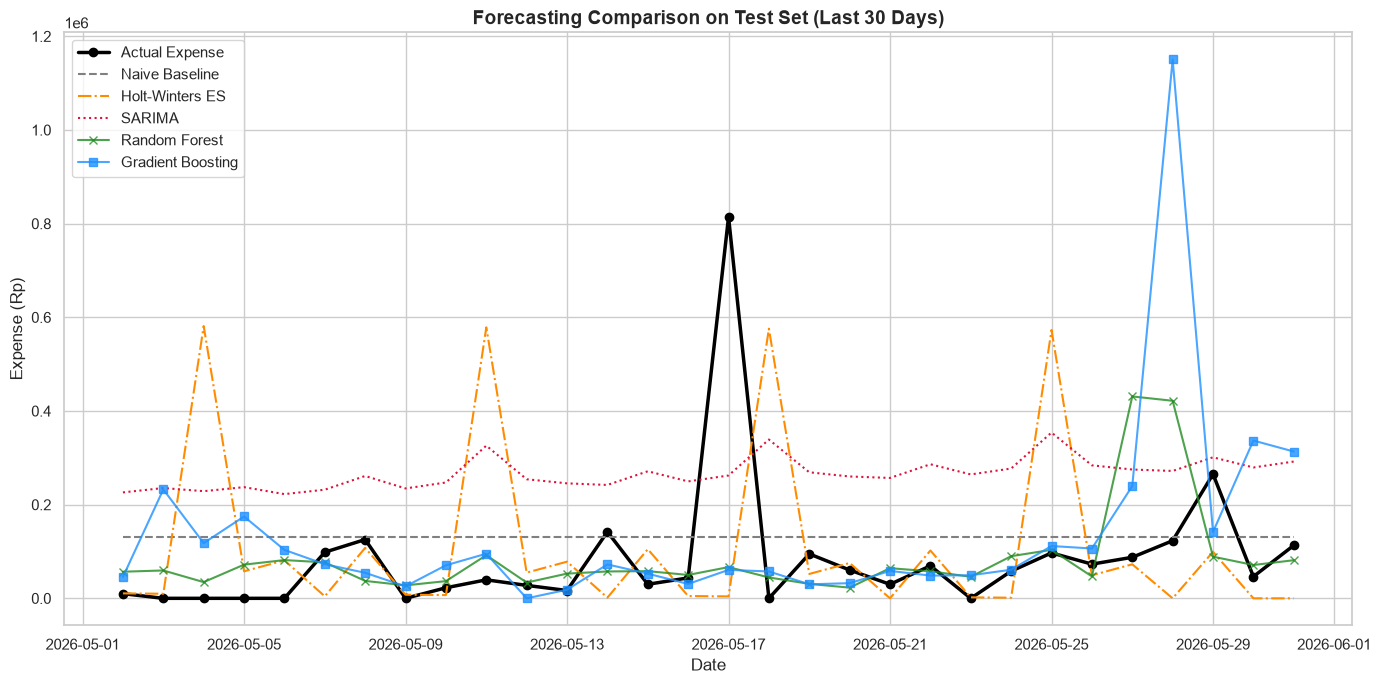

In [11]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Expense', color='black', linewidth=2.5, marker='o')
plt.plot(y_test.index, baseline_pred[-len(y_test):], label='Naive Baseline', linestyle='--', color='gray')
plt.plot(y_test.index, hw_pred[-len(y_test):], label='Holt-Winters ES', linestyle='-.', color='darkorange')
plt.plot(y_test.index, sarima_pred[-len(y_test):], label='SARIMA', linestyle=':', color='crimson')
plt.plot(y_test.index, rf_pred, label='Random Forest', color='forestgreen', marker='x', alpha=0.8)
plt.plot(y_test.index, gbr_pred, label='Gradient Boosting', color='dodgerblue', marker='s', alpha=0.8)

plt.title('Forecasting Comparison on Test Set (Last 30 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Expense (Rp)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Full Dataset Training & 30-Day Future Forecasting
We retrain the best performing model (e.g., Random Forest) on the full dataset to capture the most recent patterns. Then, we use recursive forecasting to predict expenses for the next 30 days.

In [12]:
# Train Random Forest on all available historical features
final_model = RandomForestRegressor(n_estimators=150, random_state=42)
final_model.fit(X, y)

# We set up iterative forecasting for the next 30 days
forecast_days = 30
future_dates = pd.date_range(start=daily_df.index.max() + pd.Timedelta(days=1), periods=forecast_days, freq='D')
working_series = daily_df['Expense'].copy()

for date in future_dates:
    # Compute features dynamically
    lags_dict = {}
    for lag in [1, 2, 3, 7, 14, 30]:
        lags_dict[f'lag_{lag}'] = working_series.iloc[-lag]
    lags_dict['rolling_mean_7'] = working_series.iloc[-7:].mean()
    lags_dict['rolling_std_7'] = working_series.iloc[-7:].std()
    lags_dict['rolling_mean_30'] = working_series.iloc[-30:].mean()
    lags_dict['day_of_week'] = date.dayofweek
    lags_dict['day_of_month'] = date.day
    lags_dict['month'] = date.month
    lags_dict['is_weekend'] = 1 if date.dayofweek in [5, 6] else 0
    
    # Predict next step
    feat_df = pd.DataFrame([lags_dict])[X.columns]
    pred = final_model.predict(feat_df)[0]
    pred = max(0.0, pred)  # limit expense to be non-negative
    
    # Append to series to calculate next lags
    working_series = pd.concat([working_series, pd.Series([pred], index=[date])])

future_forecast = working_series.loc[future_dates]

print("Predicted Expenses for Next 10 Days:")
print(future_forecast.head(10).apply(lambda x: f"Rp {x:,.2f}"))

Predicted Expenses for Next 10 Days:
2026-06-01     Rp 61,565.57
2026-06-02     Rp 39,772.84
2026-06-03     Rp 42,685.37
2026-06-04     Rp 93,545.41
2026-06-05     Rp 51,519.60
2026-06-06     Rp 71,255.11
2026-06-07    Rp 213,810.00
2026-06-08     Rp 44,016.66
2026-06-09     Rp 52,944.55
2026-06-10     Rp 46,618.91
dtype: str


### Plotting Future Forecasts

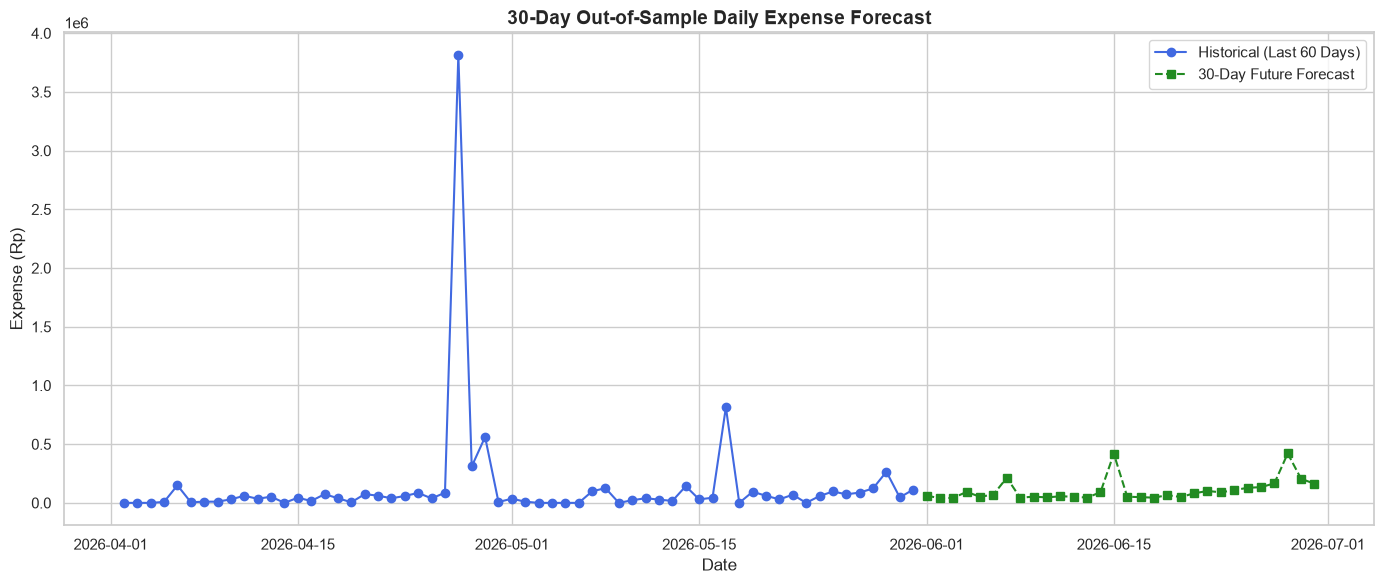

In [13]:
plt.figure(figsize=(14, 6))
hist_period = daily_df.iloc[-60:]
plt.plot(hist_period.index, hist_period['Expense'], label='Historical (Last 60 Days)', color='royalblue', marker='o')
plt.plot(future_forecast.index, future_forecast.values, label='30-Day Future Forecast', color='forestgreen', linestyle='--', marker='s')
plt.title('30-Day Out-of-Sample Daily Expense Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Expense (Rp)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Serialization for Web Deployment
Finally, we dump our trained Random Forest model and save the history data. This will allow the web application backend (FastAPI/main.py) to read files and generate predictions in real-time.

In [14]:
# Save model artifact
joblib.dump(final_model, 'expense_forecaster_rf.joblib')

# Save historical series for lag feature computation in web app
daily_df.to_csv('historical_daily_expenses.csv')

print("Artifacts exported:")
print("- Model: expense_forecaster_rf.joblib")
print("- Historical Data: historical_daily_expenses.csv")

# Snippet of what the Python backend will run:
print("\nWeb server usage example:")
print("""
import joblib
import pandas as pd
import numpy as np

model = joblib.load('expense_forecaster_rf.joblib')
history = pd.read_csv('historical_daily_expenses.csv', index_col=0, parse_dates=True)
# Generate next prediction...
""")

Artifacts exported:
- Model: expense_forecaster_rf.joblib
- Historical Data: historical_daily_expenses.csv

Web server usage example:

import joblib
import pandas as pd
import numpy as np

model = joblib.load('expense_forecaster_rf.joblib')
history = pd.read_csv('historical_daily_expenses.csv', index_col=0, parse_dates=True)
# Generate next prediction...

